# 05 — Interest Rate Swap Pricing & Analysis

**Fixed Income Analytics** | Palma, R. (2026)

This notebook prices Interest Rate Swaps from scratch
using the yield curve built in Module 2, validates the
floating leg = par proposition, and implements a classic
curve trade simulation.

### Contents
1. Setup: curve and swap schedule
2. Floating leg = par validation
3. FRA decomposition
4. Swap curve vs spot curve
5. Swap sensitivity analysis
6. Interactive swap pricer
7. Curve trade simulation
8. Portfolio of swaps

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as widgets
from ipywidgets import interactive_output
from IPython.display import display
import warnings
import os
warnings.filterwarnings("ignore")

sys.path.append("..")
from src.curves      import DiscountCurve, Bootstrapper, CurveInterpolator
from src.swaps       import VanillaIRS, SwapPortfolio
from src.bonds       import VanillaBond
from src.sensitivity import BondSensitivity

os.makedirs("../figures", exist_ok=True)

plt.rcParams.update({
    "figure.figsize":    (12, 5),
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "serif",
})

COLORS = {
    "spot":    "#2E75B6",
    "swap":    "#C00000",
    "forward": "#70AD47",
    "fixed":   "#ED7D31",
    "float":   "#7030A0",
}

print("✓ Imports OK")

✓ Imports OK


---
## 1. Setup: Curve and Swap Schedule

We build a realistic upward-sloping yield curve and
price a 10-year semi-annual IRS at the fair swap rate.

In [3]:
# ── Yield curve ───────────────────────────────────────────────
t_obs = np.array([0.25, 0.5, 1., 2., 3.,
                  5., 7., 10., 20., 30.])
r_obs = np.array([0.040, 0.041, 0.043, 0.046,
                  0.048, 0.051, 0.053, 0.055,
                  0.058, 0.060])

curve = DiscountCurve(t_obs, r_obs)

# ── Interpolator for smooth curves ───────────────────────────
interp = CurveInterpolator(curve)
beta   = interp.fit_nss()
t_fine = np.linspace(0.25, 30, 300)

# ── Reference 10y semi-annual swap ───────────────────────────
N      = 1_000_000   # $1M notional
tenor  = 10
freq   = 2           # semi-annual

# Price at fair rate K*
swap_ref = VanillaIRS(N, 0.0, tenor, freq,
                       curve, "long")
K_star   = swap_ref.swap_rate()
swap_ref = VanillaIRS(N, K_star, tenor, freq,
                       curve, "long")

print(f"Reference Swap: {swap_ref}")
print(f"\nFair Swap Rate K* = {K_star:.4%}")
print(f"Spot rate at 10y  = {curve.spot_rate(10):.4%}")
print(f"Spread K*-r(10y)  = {K_star - curve.spot_rate(10):.4%}")

sm = swap_ref.summary()
print(f"\nSwap Summary:")
for k, v in sm.items():
    print(f"  {k:22s}: {v}")

Reference Swap: VanillaIRS(N=1,000,000, K=5.4939%, tenor=10y, freq=2, position=long)

Fair Swap Rate K* = 5.4939%
Spot rate at 10y  = 5.5000%
Spread K*-r(10y)  = -0.0061%

Swap Summary:
  notional              : 1000000
  fixed_rate_K          : 0.054939
  swap_rate_K*          : 0.054939
  spread_K_Kstar        : 0.0
  fixed_leg             : 1000000.0
  float_leg             : 1000000.0
  float_eq_par          : True
  swap_value            : 0.0
  dv01                  : -779.467941
  mod_duration          : -7.794679
  position              : long


---
## 2. Floating Leg = Par: Validation

**Proposition:** $V_{\text{float}} = N$ always.

We verify this numerically across multiple curves and
tenors, and show the telescoping sum explicitly.

In [4]:
print("Floating Leg = Par Validation")
print("=" * 55)

# Test across tenors and curves
tenors_test = [1, 2, 3, 5, 7, 10, 20, 30]
freqs_test  = [1, 2, 4]

rows = []
for t in tenors_test:
    for f in freqs_test:
        # Only test tenors within curve range
        if t > t_obs.max():
            continue
        s      = VanillaIRS(N, 0.05, t, f, curve)
        v_float = s.floating_leg_value()
        rows.append({
            "Tenor": t,
            "Freq":  f,
            "V_float": round(v_float, 4),
            "N":       N,
            "Error":   round(abs(v_float - N), 6),
            "= Par?":  "✓" if np.isclose(
                v_float, N, rtol=1e-4) else "✗"
        })

df_val = pd.DataFrame(rows)
print(df_val.to_string(index=False))

# Show telescoping sum explicitly for reference swap
print(f"\nTelescoping Sum (10y semi-annual):")
Z    = swap_ref.Z
Z_prev = np.concatenate([[1.0], Z[:-1]])
diffs  = Z_prev - Z

print(f"\n  {'Period':>8} {'Z(t_prev)':>12} "
      f"{'Z(t_i)':>12} {'Difference':>12}")
print("  " + "-" * 48)
for i, (zp, zi, d) in enumerate(
        zip(Z_prev, Z, diffs)):
    print(f"  {i+1:>8} {zp:>12.6f} "
          f"{zi:>12.6f} {d:>12.6f}")

print(f"\n  Sum of differences: "
      f"{diffs.sum():.6f}")
print(f"  + Z(t_n):           {Z[-1]:.6f}")
print(f"  = Total:            {diffs.sum() + Z[-1]:.6f}")
print(f"  × N:                ${(diffs.sum() + Z[-1])*N:,.2f}")
print(f"  ✓ Equals N = ${N:,.2f}")

Floating Leg = Par Validation
 Tenor  Freq   V_float       N  Error = Par?
     1     1 1000000.0 1000000    0.0      ✓
     1     2 1000000.0 1000000    0.0      ✓
     1     4 1000000.0 1000000    0.0      ✓
     2     1 1000000.0 1000000    0.0      ✓
     2     2 1000000.0 1000000    0.0      ✓
     2     4 1000000.0 1000000    0.0      ✓
     3     1 1000000.0 1000000    0.0      ✓
     3     2 1000000.0 1000000    0.0      ✓
     3     4 1000000.0 1000000    0.0      ✓
     5     1 1000000.0 1000000    0.0      ✓
     5     2 1000000.0 1000000    0.0      ✓
     5     4 1000000.0 1000000    0.0      ✓
     7     1 1000000.0 1000000    0.0      ✓
     7     2 1000000.0 1000000    0.0      ✓
     7     4 1000000.0 1000000    0.0      ✓
    10     1 1000000.0 1000000    0.0      ✓
    10     2 1000000.0 1000000    0.0      ✓
    10     4 1000000.0 1000000    0.0      ✓
    20     1 1000000.0 1000000    0.0      ✓
    20     2 1000000.0 1000000    0.0      ✓
    20     4 1000000.0 10

---
## 3. FRA Decomposition

The swap is a portfolio of FRAs, one per payment date:

$$V_{\text{FRA}}(t_i) = N \cdot \delta_i \cdot
(f(t_{i-1}, t_i) - K) \cdot Z(t_i)$$

At fair rate K = K*, the sum is zero by definition.

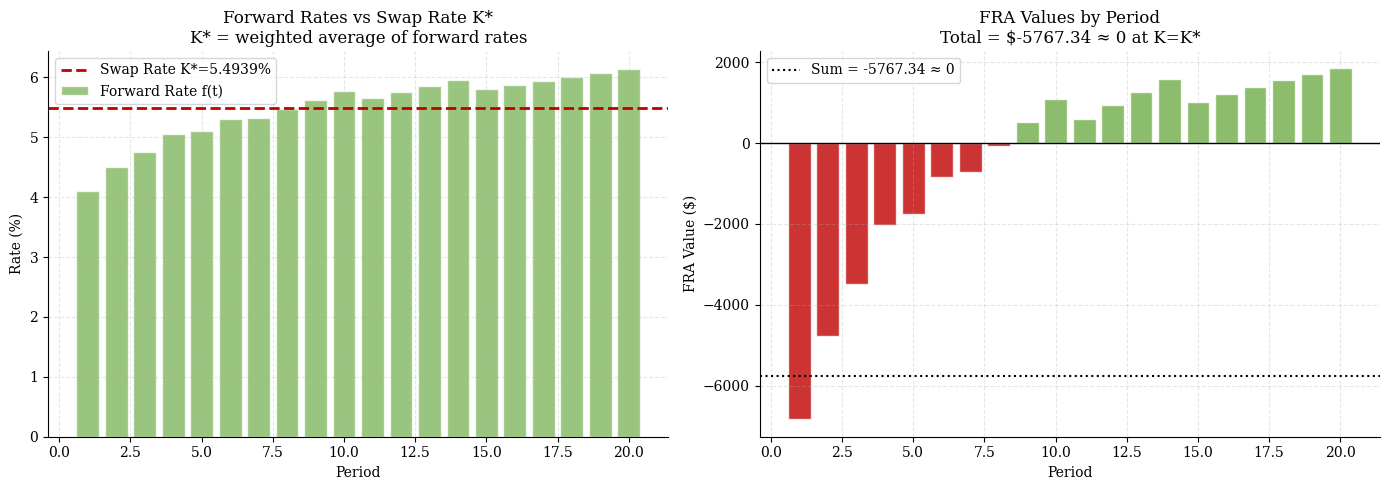


FRA Decomposition Table:
 Period  t_start  t_end   Z(t_i)  Forward Rate  Fixed Rate K    Spread  FRA Value
      1      0.0    0.5 0.979709      0.041000      0.054939 -0.013939 -6828.0390
      2      0.5    1.0 0.957911      0.045000      0.054939 -0.009939 -4760.3008
      3      1.0    1.5 0.935429      0.047500      0.054939 -0.007439 -3479.2893
      4      1.5    2.0 0.912105      0.050500      0.054939 -0.004439 -2024.3794
      5      2.0    2.5 0.889141      0.051000      0.054939 -0.003939 -1751.1252
      6      2.5    3.0 0.865888      0.053000      0.054939 -0.001939  -839.4421
      7      3.0    3.5 0.843138      0.053250      0.054939 -0.001689  -711.9947
      8      3.5    4.0 0.820370      0.054750      0.054939 -0.000189   -77.4908
      9      4.0    4.5 0.797618      0.056250      0.054939  0.001311   522.8721
     10      4.5    5.0 0.774916      0.057750      0.054939  0.002811  1089.1774
     11      5.0    5.5 0.753331      0.056500      0.054939  0.001561  

In [5]:
fra_df = swap_ref.fra_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Forward rates vs K* ─────────────────────────────────
ax = axes[0]
ax.bar(fra_df["Period"],
       fra_df["Forward Rate"] * 100,
       color=COLORS["forward"], alpha=0.7,
       edgecolor="white", label="Forward Rate f(t)")
ax.axhline(K_star * 100,
           color=COLORS["swap"], lw=2, ls="--",
           label=f"Swap Rate K*={K_star:.4%}")
ax.set_xlabel("Period")
ax.set_ylabel("Rate (%)")
ax.set_title("Forward Rates vs Swap Rate K*\n"
             "K* = weighted average of forward rates")
ax.legend()

# ── Right: FRA values ─────────────────────────────────────────
ax  = axes[1]
colors_fra = [COLORS["forward"] if v >= 0
              else COLORS["swap"]
              for v in fra_df["FRA Value"]]
ax.bar(fra_df["Period"], fra_df["FRA Value"],
       color=colors_fra, alpha=0.8,
       edgecolor="white")
ax.axhline(0, color="black", lw=1)
total_fra = fra_df["FRA Value"].sum()
ax.axhline(total_fra, color="black",
           lw=1.5, ls=":",
           label=f"Sum = {total_fra:.2f} ≈ 0")
ax.set_xlabel("Period")
ax.set_ylabel("FRA Value ($)")
ax.set_title(f"FRA Values by Period\n"
             f"Total = ${total_fra:.2f} ≈ 0 at K=K*")
ax.legend()

plt.tight_layout()
plt.savefig("../figures/05_fra_decomposition.png",
            dpi=150)
plt.show()

print("\nFRA Decomposition Table:")
print(fra_df.to_string(index=False))
print(f"\nSum of FRA values: ${fra_df['FRA Value'].sum():.4f}")

---
## 4. Swap Curve vs Spot Curve

The swap curve connects K* across different tenors.
It differs from the spot curve because K* is a
**weighted average** of forward rates, not a single
spot rate.

Key relationships:
- Swap rate K*(T) lies between short and long spot rates
- In an upward-sloping curve: K*(T) < r(T) for long tenors
- The swap spread = K*(T) - r(T) reflects the averaging effect

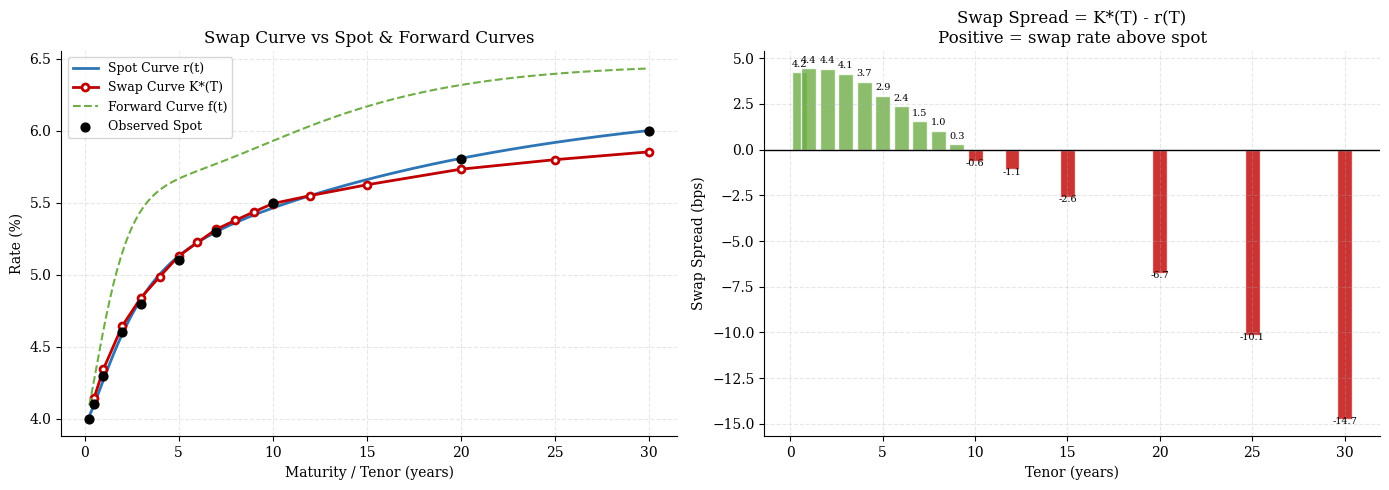

Swap Curve:

   Tenor    Spot r(T)   Swap K*(T)   Spread (bps)
--------------------------------------------------
     0.5      4.1000%      4.1423%           4.23
     1.0      4.3000%      4.3444%           4.44
     2.0      4.6000%      4.6442%           4.42
     3.0      4.8000%      4.8414%           4.14
     4.0      4.9500%      4.9872%           3.72
     5.0      5.1000%      5.1294%           2.94
     6.0      5.2000%      5.2237%           2.37
     7.0      5.3000%      5.3154%           1.54
     8.0      5.3667%      5.3768%           1.02
     9.0      5.4333%      5.4363%           0.29
    10.0      5.5000%      5.4939%          -0.61
    12.0      5.5600%      5.5491%          -1.09
    15.0      5.6500%      5.6242%          -2.58
    20.0      5.8000%      5.7327%          -6.73
    25.0      5.9000%      5.7987%         -10.13
    30.0      6.0000%      5.8528%         -14.72


In [6]:
# Compute swap rates across tenors
tenors_curve = np.array([0.5, 1, 2, 3, 4, 5,
                          6, 7, 8, 9, 10,
                          12, 15, 20, 25, 30])
swap_rates   = []
spot_rates_t = []

for t in tenors_curve:
    if t > t_obs.max():
        swap_rates.append(np.nan)
        spot_rates_t.append(np.nan)
        continue
    s  = VanillaIRS(N, 0.0, t, 2, curve)
    swap_rates.append(s.swap_rate())
    spot_rates_t.append(curve.spot_rate(t))

swap_rates   = np.array(swap_rates)
spot_rates_t = np.array(spot_rates_t)
valid        = ~np.isnan(swap_rates)

# Forward curve from NSS
fwd_curve = CurveInterpolator.nss_forward(
    t_fine, beta)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Three curves ────────────────────────────────────────
ax = axes[0]
ax.plot(t_fine,
        CurveInterpolator.nss_spot(t_fine, beta) * 100,
        color=COLORS["spot"], lw=2,
        label="Spot Curve r(t)")
ax.plot(tenors_curve[valid],
        swap_rates[valid] * 100,
        color=COLORS["swap"], lw=2,
        marker="o", markersize=5,
        markerfacecolor="white",
        markeredgewidth=2,
        label="Swap Curve K*(T)")
ax.plot(t_fine, fwd_curve * 100,
        color=COLORS["forward"], lw=1.5,
        ls="--", label="Forward Curve f(t)")
ax.scatter(t_obs, r_obs * 100,
           color="black", zorder=5,
           s=40, label="Observed Spot")
ax.set_xlabel("Maturity / Tenor (years)")
ax.set_ylabel("Rate (%)")
ax.set_title("Swap Curve vs Spot & Forward Curves")
ax.legend(fontsize=9)

# ── Right: Swap spread = K*(T) - r(T) ────────────────────────
ax      = axes[1]
spread  = (swap_rates[valid] -
           spot_rates_t[valid]) * 10000   # in bps
colors_spread = [COLORS["forward"] if s >= 0
                 else COLORS["swap"]
                 for s in spread]

ax.bar(tenors_curve[valid], spread,
       color=colors_spread, alpha=0.8,
       edgecolor="white")
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Swap Spread (bps)")
ax.set_title("Swap Spread = K*(T) - r(T)\n"
             "Positive = swap rate above spot")

# Annotate
for t, s in zip(tenors_curve[valid], spread):
    if abs(s) > 0.1:
        ax.text(t, s + np.sign(s) * 0.3,
                f"{s:.1f}",
                ha="center", fontsize=7)

plt.tight_layout()
plt.savefig("../figures/05_swap_vs_spot_curve.png",
            dpi=150)
plt.show()

# Print swap curve table
print("Swap Curve:")
print(f"\n{'Tenor':>8} {'Spot r(T)':>12} "
      f"{'Swap K*(T)':>12} {'Spread (bps)':>14}")
print("-" * 50)
for t, k, r, s in zip(
        tenors_curve[valid],
        swap_rates[valid],
        spot_rates_t[valid],
        spread):
    print(f"{t:>8.1f} {r:>12.4%} "
          f"{k:>12.4%} {s:>14.2f}")

---
## 5. Swap Sensitivity Analysis

DV01 and key rate profile of the swap.

Key insight: the swap has **no convexity** from the
floating leg (it resets to par), so all convexity
comes from the fixed leg only.

$$\text{DV01}_{\text{swap}} \approx
\text{DV01}_{\text{fixed leg}}$$
$$\text{Convexity}_{\text{swap}} \approx
\text{Convexity}_{\text{fixed leg}}$$

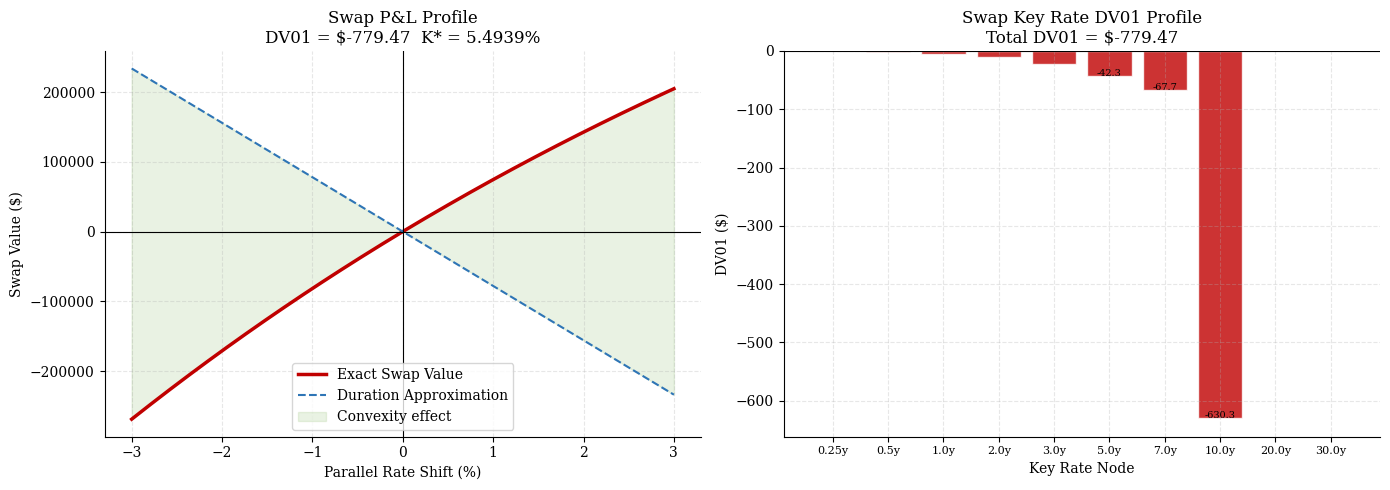

Sensitivity Decomposition:
  DV01 total swap:     $-779.4679
  Floating leg DV01:   ~$0 (resets to par)
  Fixed leg DV01:      $-779.4679

Key Rate DV01:
   0.25y: $    0.0000
    0.5y: $   -1.3456
    1.0y: $   -4.5585
    2.0y: $   -9.9912
    3.0y: $  -23.2402
    5.0y: $  -42.3130
    7.0y: $  -67.7291
   10.0y: $ -630.2903
   20.0y: $    0.0000
   30.0y: $    0.0000


In [7]:
# ── Swap value vs rate shift ──────────────────────────────────
rate_shifts = np.linspace(-0.03, 0.03, 200)
pnl_df      = swap_ref.value_vs_rate(rate_shifts)

# Compare with duration approximation
dv01_ref  = swap_ref.dv01()
V_fixed   = swap_ref.fixed_leg_value()

# Get fixed leg bond equivalent for convexity
# Fixed leg ≈ coupon bond with K* coupons
bond_equiv = VanillaBond(K_star, N, tenor, freq)
bond_sens  = BondSensitivity(bond_equiv, curve)
bond_met   = bond_sens.summary()
Cx_fixed   = bond_met["krd"]

# Linear approximation (duration only)
pnl_linear = dv01_ref * rate_shifts / 0.0001

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: P&L profile ─────────────────────────────────────────
ax = axes[0]
ax.plot(rate_shifts * 100,
        pnl_df["Swap Value"],
        color=COLORS["swap"], lw=2.5,
        label="Exact Swap Value")
ax.plot(rate_shifts * 100, pnl_linear,
        color=COLORS["spot"], lw=1.5,
        ls="--", label="Duration Approximation")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.fill_between(rate_shifts * 100,
                pnl_df["Swap Value"],
                pnl_linear,
                alpha=0.15, color=COLORS["forward"],
                label="Convexity effect")
ax.set_xlabel("Parallel Rate Shift (%)")
ax.set_ylabel("Swap Value ($)")
ax.set_title(f"Swap P&L Profile\n"
             f"DV01 = ${dv01_ref:,.2f}  "
             f"K* = {K_star:.4%}")
ax.legend()

# ── Right: Key rate DV01 profile ──────────────────────────────
ax      = axes[1]
krd_dv01 = swap_ref.key_rate_dv01()
nodes    = list(krd_dv01.keys())
vals     = list(krd_dv01.values())

colors_krd = [COLORS["forward"] if v >= 0
              else COLORS["swap"]
              for v in vals]
ax.bar(range(len(nodes)), vals,
       color=colors_krd, alpha=0.8,
       edgecolor="white")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(range(len(nodes)))
ax.set_xticklabels(
    [f"{t}y" for t in nodes], fontsize=8)
ax.set_xlabel("Key Rate Node")
ax.set_ylabel("DV01 ($)")
ax.set_title(f"Swap Key Rate DV01 Profile\n"
             f"Total DV01 = ${sum(vals):,.2f}")

# Annotate
for i, v in enumerate(vals):
    if abs(v) > abs(max(vals, key=abs)) * 0.05:
        ax.text(i, v + np.sign(v) * abs(max(vals)) * 0.02,
                f"{v:.1f}",
                ha="center", fontsize=7)

plt.tight_layout()
plt.savefig("../figures/05_swap_sensitivity.png",
            dpi=150)
plt.show()

# Fixed vs floating DV01
print(f"Sensitivity Decomposition:")
print(f"  DV01 total swap:     ${dv01_ref:,.4f}")
print(f"  Floating leg DV01:   ~$0 (resets to par)")
print(f"  Fixed leg DV01:      ${dv01_ref:,.4f}")
print(f"\nKey Rate DV01:")
for t, dv in krd_dv01.items():
    print(f"  {t:>5}y: ${dv:>10.4f}")

---
## 6. Interactive Swap Pricer

Price any vanilla IRS in real time. Observe how
K* depends on tenor and frequency, and how the
swap value changes as rates move.

In [8]:
def plot_swap_pricer(tenor, freq_idx,
                     k_spread_bps, notional_m):
    """Interactive swap pricer."""
    freqs      = [1, 2, 4]
    freq_names = ["Annual", "Semi-annual", "Quarterly"]
    freq       = freqs[freq_idx]
    N_swap     = notional_m * 1_000_000

    if tenor > t_obs.max():
        print(f"Tenor {tenor}y exceeds curve range "
              f"({t_obs.max()}y)")
        return

    # Fair rate
    s_fair = VanillaIRS(N_swap, 0.0, tenor,
                         freq, curve)
    K_fair = s_fair.swap_rate()
    K      = K_fair + k_spread_bps / 10000

    # Price swap
    swap = VanillaIRS(N_swap, K, tenor,
                       freq, curve, "long")

    # P&L profile
    shifts = np.linspace(-0.03, 0.03, 200)
    pnl    = swap.value_vs_rate(shifts)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left: Leg values ──────────────────────────────────────
    ax = axes[0]
    ax.bar(["Fixed Leg", "Floating Leg", "Net Value"],
           [swap.fixed_leg_value(),
            swap.floating_leg_value(),
            swap.value()],
           color=[COLORS["fixed"],
                  COLORS["float"],
                  COLORS["swap"]
                  if swap.value() >= 0
                  else COLORS["swap"]],
           alpha=0.8, edgecolor="white")
    ax.axhline(0, color="black", lw=1)
    ax.axhline(N_swap, color="gray",
               lw=1, ls=":", label=f"Notional = ${N_swap/1e6:.0f}M")
    ax.set_ylabel("Value ($)")
    ax.set_title(
        f"{tenor}y {freq_names[freq_idx]} Swap\n"
        f"K={K:.4%}  K*={K_fair:.4%}  "
        f"Spread={k_spread_bps:+.0f}bps"
    )
    ax.legend(fontsize=9)

    # Add value labels
    for i, (label, val) in enumerate(zip(
            ["Fixed Leg", "Float Leg", "Net"],
            [swap.fixed_leg_value(),
             swap.floating_leg_value(),
             swap.value()])):
        ax.text(i, val + np.sign(val) * N_swap * 0.01,
                f"${val/1e6:.3f}M",
                ha="center", fontsize=9,
                fontweight="bold")

    # ── Right: P&L vs rate shift ──────────────────────────────
    ax = axes[1]
    ax.plot(shifts * 100,
            pnl["Swap Value"],
            color=COLORS["swap"], lw=2.5)
    ax.fill_between(shifts * 100,
                    pnl["Swap Value"], 0,
                    where=pnl["Swap Value"] >= 0,
                    alpha=0.2,
                    color=COLORS["forward"])
    ax.fill_between(shifts * 100,
                    pnl["Swap Value"], 0,
                    where=pnl["Swap Value"] < 0,
                    alpha=0.2,
                    color=COLORS["swap"])
    ax.axhline(0, color="black", lw=1)
    ax.axvline(0, color="black", lw=0.8, ls=":")
    ax.set_xlabel("Parallel Rate Shift (%)")
    ax.set_ylabel("Swap Value ($)")
    ax.set_title(
        f"P&L Profile\n"
        f"DV01=${swap.dv01():,.0f}  "
        f"V=${swap.value():,.0f}")

    plt.tight_layout()
    plt.show()

# ── Widgets ───────────────────────────────────────────────────
style  = {"description_width": "140px"}
layout = widgets.Layout(width="500px")

w_tenor = widgets.IntSlider(
    value=10, min=1, max=30, step=1,
    description="Tenor (years):",
    style=style, layout=layout
)
w_freq = widgets.RadioButtons(
    options=[("Annual (1)", 0),
             ("Semi-annual (2)", 1),
             ("Quarterly (4)", 2)],
    value=1,
    description="Frequency:",
    style=style
)
w_spread = widgets.IntSlider(
    value=0, min=-100, max=100, step=5,
    description="Spread vs K* (bps):",
    style=style, layout=layout
)
w_notional = widgets.FloatSlider(
    value=1.0, min=0.1, max=10.0, step=0.1,
    description="Notional ($M):",
    style=style, layout=layout,
    readout_format=".1f"
)

# Preset buttons
def payer_atm(_):
    w_tenor.value=10; w_spread.value=0
def payer_offmkt(_):
    w_tenor.value=10; w_spread.value=50
def short_swap(_):
    w_tenor.value=2; w_spread.value=0
def long_swap(_):
    w_tenor.value=30; w_spread.value=0

btn_atm   = widgets.Button(description="10y At Market",
                            button_style="info")
btn_off   = widgets.Button(description="10y Off Market +50bps",
                            button_style="warning")
btn_short = widgets.Button(description="2y Swap",
                            button_style="")
btn_long  = widgets.Button(description="30y Swap",
                            button_style="danger")

btn_atm.on_click(payer_atm)
btn_off.on_click(payer_offmkt)
btn_short.on_click(short_swap)
btn_long.on_click(long_swap)

out = interactive_output(
    plot_swap_pricer,
    {"tenor":       w_tenor,
     "freq_idx":    w_freq,
     "k_spread_bps": w_spread,
     "notional_m":  w_notional}
)

display(widgets.HTML("<h4>Presets:</h4>"))
display(widgets.HBox([btn_atm, btn_off,
                      btn_short, btn_long]))
display(widgets.HTML("<br><h4>Swap Parameters:</h4>"))
display(widgets.VBox([w_tenor, w_freq,
                      w_spread, w_notional]))
display(out)

HTML(value='<h4>Presets:</h4>')

HTML(value='<br><h4>Swap Parameters:</h4>')

Output()

---
## 7. Curve Trade Simulation

Classic fixed income trade: profit from yield curve
flattening regardless of the absolute level of rates.

**Structure:**
- Pay fixed in short-dated swap (long 2y)
- Receive fixed in long-dated swap (short 10y)

**Thesis:** if the curve flattens (spread 10y-2y narrows),
the long-dated receiver benefits more than the
short-dated payer loses.

In [11]:
def plot_curve_trade(short_tenor, long_tenor,
                     parallel_shift_bps,
                     slope_change_bps):
    """
    Curve trade P&L simulation.

    parallel_shift: moves all rates equally
    slope_change:   moves long rates vs short rates
                    positive = steepening
                    negative = flattening
    """
    N_trade = 1_000_000

    if (short_tenor >= long_tenor or
            long_tenor > t_obs.max()):
        print("Invalid tenors. Ensure short < long "
              "and long ≤ curve max.")
        return

    # Build curve trade
    trade = SwapPortfolio.curve_trade(
        N_trade, short_tenor, long_tenor,
        2, curve)

    # Current values
    V0 = trade.total_value()

    # Shifted curve: parallel + slope
    # Slope change shifts long end more than short end
    t_max    = t_obs.max()
    parallel = parallel_shift_bps / 10000
    slope    = slope_change_bps / 10000

    slope_vec = np.array([
        parallel + slope * (t / t_max)
        for t in t_obs
    ])

    curve_shifted = DiscountCurve(
        t_obs,
        np.clip(r_obs + slope_vec, 0.001, None)
    )

    V1     = trade.total_value(curve_shifted)
    pnl    = V1 - V0
    spread_0 = (curve.spot_rate(long_tenor) -
                curve.spot_rate(short_tenor)) * 10000
    spread_1 = (curve_shifted.spot_rate(long_tenor) -
                curve_shifted.spot_rate(short_tenor)) * 10000

    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig,
                            hspace=0.4, wspace=0.35)

    # ── Top left: Original vs shifted curve ──────────────────
    ax = fig.add_subplot(gs[0, 0])
    ax.plot(t_fine,
            CurveInterpolator.nss_spot(t_fine, beta) * 100,
            color=COLORS["spot"], lw=2,
            label="Original Curve")

    interp_sh = CurveInterpolator(curve_shifted)
    beta_sh   = interp_sh.fit_nss()
    ax.plot(t_fine,
            CurveInterpolator.nss_spot(
                t_fine, beta_sh) * 100,
            color=COLORS["swap"], lw=2, ls="--",
            label="Shifted Curve")
    ax.scatter(t_obs, r_obs * 100,
               color="black", s=30, zorder=5)
    ax.scatter(t_obs,
               (r_obs + slope_vec) * 100,
               color=COLORS["swap"], s=30,
               zorder=5, marker="s")
    ax.axvline(short_tenor, color="gray",
               ls=":", lw=1)
    ax.axvline(long_tenor, color="gray",
               ls=":", lw=1)
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Rate (%)")
    ax.set_title(
        f"Yield Curve Shift\n"
        f"Parallel: {parallel_shift_bps:+.0f}bps  "
        f"Slope: {slope_change_bps:+.0f}bps"
    )
    ax.legend(fontsize=9)

    # ── Top right: Spread change ──────────────────────────────
    ax = fig.add_subplot(gs[0, 1])
    spreads = [spread_0, spread_1]
    colors_bar = [COLORS["spot"], COLORS["swap"]]
    ax.bar(["Original", "Shifted"],
           spreads, color=colors_bar,
           alpha=0.8, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8)
    for i, s in enumerate(spreads):
        ax.text(i, s + 0.5,
                f"{s:.1f}bps",
                ha="center", fontsize=11,
                fontweight="bold")
    ax.set_ylabel("Spread (bps)")
    ax.set_title(
        f"Curve Spread: {long_tenor}y - {short_tenor}y\n"
        f"Change: {spread_1-spread_0:+.1f}bps"
    )

    # ── Bottom left: P&L by swap leg ─────────────────────────
    ax   = fig.add_subplot(gs[1, 0])
    pnls = []
    lbls = []
    for label, swap in zip(trade.labels, trade.swaps):
        pnl_i = swap.value(curve_shifted) - swap.value()
        pnls.append(pnl_i)
        lbls.append(label)

    color_pnl = [COLORS["forward"] if p >= 0
                 else COLORS["swap"]
                 for p in pnls]
    ax.bar(range(len(lbls)), pnls,
           color=color_pnl, alpha=0.8,
           edgecolor="white")
    ax.axhline(0, color="black", lw=1)
    ax.axhline(pnl, color="black",
               lw=2, ls="--",
               label=f"Total P&L: ${pnl:,.0f}")
    ax.set_xticks(range(len(lbls)))
    ax.set_xticklabels(lbls, fontsize=8)
    ax.set_ylabel("P&L ($)")
    ax.set_title("P&L by Swap Leg")
    ax.legend(fontsize=9)

    for i, p in enumerate(pnls):
        ax.text(i, p + np.sign(p) * abs(pnl) * 0.05,
                f"${p:,.0f}",
                ha="center", fontsize=9,
                fontweight="bold")

    # ── Bottom right: P&L heatmap vs slope/parallel ──────────
    ax = fig.add_subplot(gs[1, 1])
    par_range   = np.linspace(-200, 200, 20)
    slope_range = np.linspace(-200, 200, 20)
    pnl_matrix  = np.zeros(
        (len(slope_range), len(par_range)))

    for i, sl in enumerate(slope_range):
        for j, pa in enumerate(par_range):
            sv = np.array([
                pa/10000 + (sl/10000) * (t/t_max)
                for t in t_obs
            ])
            c_ij = DiscountCurve(
                t_obs,
                np.clip(r_obs + sv, 0.001, None)
            )
            pnl_matrix[i, j] = (
                trade.total_value(c_ij) - V0)

    im = ax.imshow(pnl_matrix,
                   extent=[-200, 200, -200, 200],
                   aspect="auto",
                   cmap="RdYlGn",
                   origin="lower")
    ax.axhline(0, color="black", lw=1, ls="--")
    ax.axvline(0, color="black", lw=1, ls="--")
    ax.scatter([parallel_shift_bps],
               [slope_change_bps],
               color="blue", s=100,
               zorder=5, marker="*",
               label="Current scenario")
    plt.colorbar(im, ax=ax, label="P&L ($)")
    ax.set_xlabel("Parallel Shift (bps)")
    ax.set_ylabel("Slope Change (bps)")
    ax.set_title(
        f"P&L Heatmap\n"
        f"Green = profit  Red = loss"
    )
    ax.legend(fontsize=8)

    plt.suptitle(
        f"Curve Trade: Pay Fixed {short_tenor}y  |  "
        f"Recv Fixed {long_tenor}y\n"
        f"Total P&L = ${pnl:,.0f}  "
        f"Spread change = {spread_1-spread_0:+.1f}bps",
        fontsize=12, y=1.01
    )
    plt.show()

# ── Widgets ───────────────────────────────────────────────────
style  = {"description_width": "140px"}
layout = widgets.Layout(width="500px")

w_short_t = widgets.IntSlider(
    value=2, min=1, max=10, step=1,
    description="Short tenor (y):",
    style=style, layout=layout
)
w_long_t = widgets.IntSlider(
    value=10, min=5, max=30, step=1,
    description="Long tenor (y):",
    style=style, layout=layout
)
w_parallel = widgets.IntSlider(
    value=0, min=-200, max=200, step=10,
    description="Parallel shift (bps):",
    style=style, layout=layout
)
w_slope = widgets.IntSlider(
    value=-50, min=-200, max=200, step=10,
    description="Slope change (bps):",
    style=style, layout=layout
)

# Presets
def flattener(_):
    w_slope.value=-50; w_parallel.value=0
def steepener(_):
    w_slope.value=50; w_parallel.value=0
def bear_flat(_):
    w_slope.value=-30; w_parallel.value=100
def bull_steep(_):
    w_slope.value=50; w_parallel.value=-100
def reset_trade(_):
    w_slope.value=0; w_parallel.value=0

btn_flat  = widgets.Button(
    description="Flattener",
    button_style="info")
btn_steep = widgets.Button(
    description="Steepener",
    button_style="warning")
btn_bf    = widgets.Button(
    description="Bear Flatten",
    button_style="danger")
btn_bs    = widgets.Button(
    description="Bull Steepen",
    button_style="success")
btn_rst   = widgets.Button(
    description="Reset",
    button_style="")

btn_flat.on_click(flattener)
btn_steep.on_click(steepener)
btn_bf.on_click(bear_flat)
btn_bs.on_click(bull_steep)
btn_rst.on_click(reset_trade)

out_trade = interactive_output(
    plot_curve_trade,
    {"short_tenor":        w_short_t,
     "long_tenor":         w_long_t,
     "parallel_shift_bps": w_parallel,
     "slope_change_bps":   w_slope}
)

display(widgets.HTML("<h4>Scenarios:</h4>"))
display(widgets.HBox([btn_flat, btn_steep,
                      btn_bf, btn_bs, btn_rst]))
display(widgets.HTML(
    "<br><h4>Trade & Curve Parameters:</h4>"))
display(widgets.VBox([w_short_t, w_long_t,
                      w_parallel, w_slope]))
display(out_trade)

HTML(value='<h4>Scenarios:</h4>')

HTML(value='<br><h4>Trade & Curve Parameters:</h4>')

Output()

---
## 8. Portfolio of Swaps

Aggregate risk across multiple swaps with different
tenors and positions.

Swap Portfolio Summary:
                         Notional        K       K*   Spread  Value       DV01     D_mod Position Float=Par
Swap                                                                                                       
Pay Fixed 2y ($500k)      500,000  4.6442%  4.6442%  0.0000%   0.00   -96.6385   -1.9328     long         ✓
Pay Fixed 5y ($1M)      1,000,000  5.1294%  5.1294%  0.0000%   0.00  -446.9386   -4.4694     long         ✓
Recv Fixed 10y ($750k)    750,000  5.4939%  5.4939%  0.0000%  -0.00   584.6010    7.7947    short         ✓
Pay Fixed 20y ($500k)     500,000  5.7327%  5.7327%  0.0000%   0.00  -599.8381  -11.9968     long         ✓
TOTAL                                                          0.00  -558.8143                             

Total Portfolio Value: $0.00
Total DV01:           $-558.8143


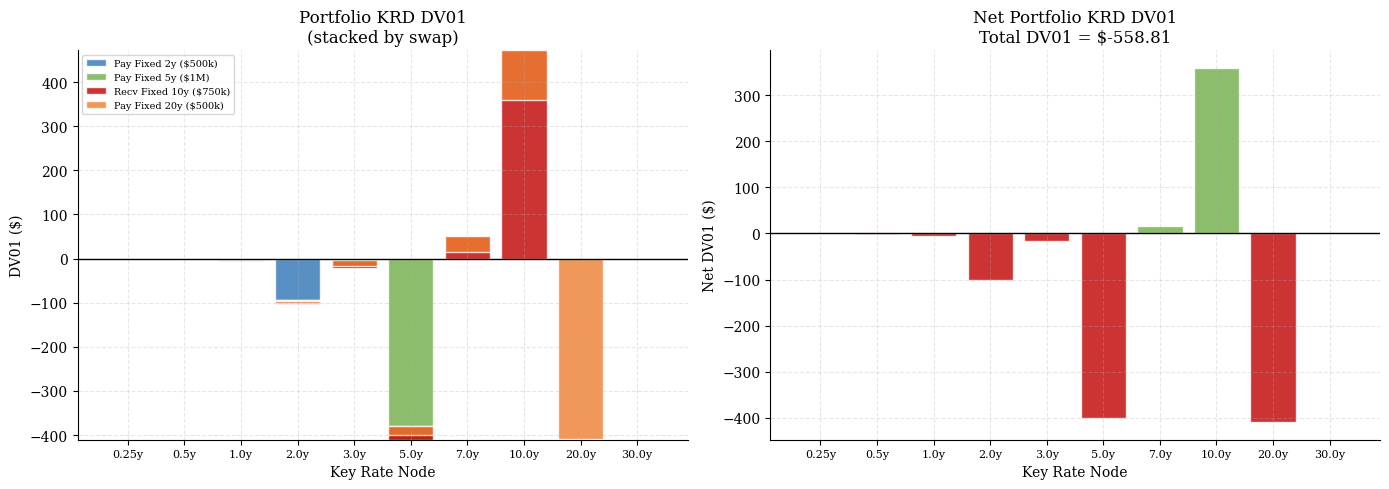

In [10]:
# Build multi-swap portfolio
swaps_port = [
    VanillaIRS(500_000,
               VanillaIRS(500_000, 0, 2, 2,
                           curve).swap_rate(),
               2, 2, curve, "long"),
    VanillaIRS(1_000_000,
               VanillaIRS(1_000_000, 0, 5, 2,
                           curve).swap_rate(),
               5, 2, curve, "long"),
    VanillaIRS(750_000,
               VanillaIRS(750_000, 0, 10, 2,
                           curve).swap_rate(),
               10, 2, curve, "short"),
    VanillaIRS(500_000,
               VanillaIRS(500_000, 0, 20, 2,
                           curve).swap_rate(),
               20, 2, curve, "long"),
]

labels_port = [
    "Pay Fixed 2y ($500k)",
    "Pay Fixed 5y ($1M)",
    "Recv Fixed 10y ($750k)",
    "Pay Fixed 20y ($500k)"
]

port_swap = SwapPortfolio(swaps_port, labels_port)

# Summary table
print("Swap Portfolio Summary:")
print(port_swap.summary_table().to_string())
print(f"\nTotal Portfolio Value: "
      f"${port_swap.total_value():,.2f}")
print(f"Total DV01:           "
      f"${port_swap.total_dv01():,.4f}")

# KRD visualization
krd_port  = port_swap.key_rate_dv01()
nodes_p   = list(krd_port.keys())
vals_p    = list(krd_port.values())

# Individual contributions
ind_krds = []
for swap in swaps_port:
    krd_i = swap.key_rate_dv01()
    ind_krds.append([krd_i.get(t, 0) for t in nodes_p])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_p  = [COLORS["spot"], COLORS["forward"],
             COLORS["swap"], COLORS["fixed"]]

# ── Left: Stacked KRD ────────────────────────────────────────
ax     = axes[0]
bottom = np.zeros(len(nodes_p))
for label, krd_i, color in zip(
        labels_port, ind_krds, colors_p):
    ax.bar(range(len(nodes_p)), krd_i,
           bottom=bottom,
           label=label, color=color,
           alpha=0.8, edgecolor="white")
    bottom += np.array(krd_i)

ax.axhline(0, color="black", lw=1)
ax.set_xticks(range(len(nodes_p)))
ax.set_xticklabels(
    [f"{t}y" for t in nodes_p], fontsize=8)
ax.set_xlabel("Key Rate Node")
ax.set_ylabel("DV01 ($)")
ax.set_title("Portfolio KRD DV01\n(stacked by swap)")
ax.legend(fontsize=7, loc="upper left")

# ── Right: Net KRD ────────────────────────────────────────────
ax = axes[1]
colors_net = [COLORS["forward"] if v >= 0
              else COLORS["swap"]
              for v in vals_p]
ax.bar(range(len(nodes_p)), vals_p,
       color=colors_net, alpha=0.8,
       edgecolor="white")
ax.axhline(0, color="black", lw=1)
ax.set_xticks(range(len(nodes_p)))
ax.set_xticklabels(
    [f"{t}y" for t in nodes_p], fontsize=8)
ax.set_xlabel("Key Rate Node")
ax.set_ylabel("Net DV01 ($)")
ax.set_title(
    f"Net Portfolio KRD DV01\n"
    f"Total DV01 = ${sum(vals_p):,.2f}")

plt.tight_layout()
plt.savefig("../figures/05_portfolio_krd.png",
            dpi=150)
plt.show()

---
## Key Observations

1. **Floating leg = par** holds exactly for any curve
   shape, tenor or frequency. The telescoping sum
   is not an approximation — it is exact.

2. **Swap curve < spot curve** for long tenors in an
   upward-sloping environment: K* is a weighted average
   of forward rates, which are below the spot rate
   at long maturities when the curve is steep.

3. **Convexity is positive** for the swap (coming from
   the fixed leg). Long-dated swaps benefit more from
   rate falls than they lose from equal rate rises.

4. **Curve trade** is P&L-neutral to parallel shifts
   when DV01s are matched. Profit/loss comes purely
   from the change in the slope of the curve.

5. **P&L heatmap** reveals the trade's exposure:
   any scenario with negative slope change (flattening)
   generates profit for the flattener trade,
   regardless of the parallel level.